# Different LLM Models Pipeline

This notebook first rebuilds `data/different_llm_models.xlsx` from `data/final results.xlsx`, then produces the boxplot-based analyses.

Analysis choices used here:

All plots below use only rows with `mode == "test"`.

1. Convergence is measured with normalized convergence AUC on standard test rows. The left subplot uses available `without optimizer` rows with `n_pop <= 10`; the right subplot uses available `with optimizer` rows with `n_pop <= 20`. The x-axis is ordered from the weakest to strongest model using a fixed smartness ranking. DeepSeek enters both panels through `S 4.1` for `without optimizer` and `S 3` for `with optimizer`. Smaller AUC means `avg_top1` falls faster toward the best observed cost for the same instance and optimizer setting. The boxplot below shows the first `n_pop` at which each LLM reaches the best observed cost for that instance, if it ever does.
2. Across-run variance is measured on the shared six-model test slice at `n_pop = 20` from `S 4.4 no opt extension`, using the coefficient of variation of the top-1 result across the 10 runs.
3. Optimizer impact is measured on matched standard test rows by comparing `avg_top1` with and without optimizer across all LLMs that have both settings.


---
### Data Preperation
---

In [1]:
from pathlib import Path
import pandas as pd
from different_llm_models_helpers import build_different_llm_workbook


In [2]:
SOURCE_WORKBOOK = Path("data/final results.xlsx")
OUTPUT_WORKBOOK = Path("data/different_llm_models.xlsx")
Path("plots").mkdir(exist_ok=True)

combined = build_different_llm_workbook(SOURCE_WORKBOOK, OUTPUT_WORKBOOK)

# Keep only test rows and compute policy metrics used throughout the notebook.
combined = combined.loc[combined["mode"].astype(str).str.lower().eq("test")].copy()

combined.shape


(2250, 124)

In [3]:
display(
    combined.loc[
        combined["mode"].astype(str).str.lower().eq("test"),
        ["source_sheet", "optimizer_status", "with_optimizer"],
    ]
    .value_counts()
    .rename("n")
    .reset_index()
    .sort_values(["source_sheet", "optimizer_status"])
)


,source_sheet,optimizer_status,with_optimizer,n
1,S 3,with optimizer,True,300
4,S 4.1,without optimizer,False,60
3,S 4.4,with optimizer,True,150
2,S 4.4 no opt,without optimizer,False,300
0,S 4.4 no opt extension,without optimizer,False,1440


In [4]:
import matplotlib.pyplot as plt
from IPython.display import display

from generalization_helpers import build_group_panel, boxplot_on_axis, format_axis
from different_llm_models_helpers import (
    ALL_MODEL_ORDER,
    OPTIMIZER_MODEL_ORDER,
    build_different_llm_workbook,
    build_metric_summary,
    compute_best_cost_reach_iteration,
    compute_normalized_convergence_auc,
    compute_optimizer_impact,
    compute_run_variance,
    llm_colors,
    llm_labels,
    load_different_llm_data,
    prepare_matched_optimizer_convergence_slice,
    SMARTNESS_ORDER,
)

plt.rc("text", usetex=True)
plt.rc("font", family="serif")


In [5]:
df = load_different_llm_data(OUTPUT_WORKBOOK)
test_df = df.loc[df["mode"].astype(str).str.lower().eq("test")].copy()

convergence_without_opt_slice = prepare_matched_optimizer_convergence_slice(
    test_df,
    "without optimizer",
    max_n_pop=20,
)
convergence_with_opt_slice = prepare_matched_optimizer_convergence_slice(
    test_df,
    "with optimizer",
    max_n_pop=20,
)

convergence_without_opt_df = compute_normalized_convergence_auc(
    convergence_without_opt_slice
).dropna(subset=["normalized_convergence_auc"])
convergence_with_opt_df = compute_normalized_convergence_auc(
    convergence_with_opt_slice
).dropna(subset=["normalized_convergence_auc"])
variance_df = compute_run_variance(test_df, n_pop=20).dropna(subset=["top1_run_cv_pct"])
optimizer_df = compute_optimizer_impact(test_df).dropna(subset=["optimizer_gain_pct"])

convergence_without_opt_summary = build_metric_summary(
    convergence_without_opt_df,
    "normalized_convergence_auc",
).rename(columns={"mean": "mean_auc", "median": "median_auc"})
convergence_with_opt_summary = build_metric_summary(
    convergence_with_opt_df,
    "normalized_convergence_auc",
).rename(columns={"mean": "mean_auc", "median": "median_auc"})
variance_summary = build_metric_summary(variance_df, "top1_run_cv_pct").rename(
    columns={"mean": "mean_cv_pct", "median": "median_cv_pct"}
)
optimizer_summary = build_metric_summary(optimizer_df, "optimizer_gain_pct").rename(
    columns={"mean": "mean_gain_pct", "median": "median_gain_pct"}
)


In [6]:
display(
    convergence_without_opt_summary.assign(
        optimizer_status="without optimizer",
        LLM=convergence_without_opt_summary["LLM"].map(lambda value: llm_labels([value])[0]),
    )[["optimizer_status", "LLM", "mean_auc", "median_auc", "min", "max", "count"]]
)
display(
    convergence_with_opt_summary.assign(
        optimizer_status="with optimizer",
        LLM=convergence_with_opt_summary["LLM"].map(lambda value: llm_labels([value])[0]),
    )[["optimizer_status", "LLM", "mean_auc", "median_auc", "min", "max", "count"]]
)
display(variance_summary.assign(LLM=variance_summary["LLM"].map(lambda value: llm_labels([value])[0])))
display(optimizer_summary.assign(LLM=optimizer_summary["LLM"].map(lambda value: llm_labels([value])[0])))


,optimizer_status,LLM,mean_auc,median_auc,min,max,count
0,without optimizer,DeepSeek,0.94,0.99,0.84,1.00,3
1,without optimizer,Gemini 2.5 Flash Lite,0.76,0.68,0.64,0.96,3
2,without optimizer,Gemini 3 Flash Preview,0.15,0.10,0.10,0.25,3
3,without optimizer,GPT-5 mini,0.79,0.82,0.56,0.98,3
4,without optimizer,GPT-5 nano,0.38,0.37,0.36,0.42,3
5,without optimizer,Grok 4.1 fast,0.67,0.56,0.46,0.99,3


,optimizer_status,LLM,mean_auc,median_auc,min,max,count
0,with optimizer,DeepSeek,0.26,0.25,0.17,0.41,30
1,with optimizer,Gemini 2.5 Flash Lite,0.74,0.78,0.57,0.86,3
2,with optimizer,Gemini 3 Flash Preview,0.24,0.30,0.00,0.42,3
3,with optimizer,GPT-5 mini,0.23,0.16,0.15,0.39,3
4,with optimizer,GPT-5 nano,0.28,0.26,0.16,0.41,3
5,with optimizer,Grok 4.1 fast,0.49,0.41,0.34,0.70,3


,LLM,mean_cv_pct,median_cv_pct,min,max,count
0,DeepSeek,3.00,0.02,0.00,24.12,12
1,Gemini 2.5 Flash Lite,11.02,5.45,0.03,27.42,12
2,Gemini 3 Flash Preview,12.45,5.69,2.33,29.80,12
3,GPT-5 mini,14.35,14.95,0.44,33.37,12
4,GPT-5 nano,14.03,10.11,3.74,36.02,12
5,Grok 4.1 fast,7.81,6.53,2.98,17.75,12


,LLM,mean_gain_pct,median_gain_pct,min,max,count
0,DeepSeek,41.14,40.63,14.52,72.71,30
1,Gemini 2.5 Flash Lite,18.82,21.68,3.01,34.76,30
2,Gemini 3 Flash Preview,13.20,10.55,7.53,44.96,30
3,GPT-5 mini,39.21,35.27,10.30,73.26,30
4,GPT-5 nano,35.61,39.11,8.44,59.19,30
5,Grok 4.1 fast,30.38,32.55,3.16,59.92,30


---
### Percent Gap to Best Repeat Baseline
---

For this section, the percentage gap is computed from the repeat-level top-1 costs, not from the already-averaged `avg_top1` column.

For a fixed problem instance $i$, first define the baseline as the smallest top-1 cost observed anywhere for that same instance across all LLMs, both optimizer settings, all available iterations $n_{\mathrm{pop}}$, and all 10 repeats:

$$
B_i = \min_{m,o,n,r} C_{i,m,o,n,r}.
$$

Here, $C_{i,m,o,n,r}$ is the top-1 cost from instance $i$, LLM model $m$, optimizer status $o$, iteration count $n_{\mathrm{pop}}=n$, and repeat $r$. In the spreadsheet, these repeat-level top-1 costs are the columns `repeat_1`, `repeat_2`, ..., `repeat_10`. The baseline $B_i$ is therefore the best cost found for that instance by any model/configuration/repeat in this analysis.

Then, for each row and repeat, the percent gap to this baseline is

$$
\mathrm{gap}_{i,m,o,n,r}(\%) = 100 \times \frac{C_{i,m,o,n,r} - B_i}{B_i}.
$$

A value of $0\%$ means that repeat exactly reached the best observed cost for that instance. A value of $10\%$ means the repeat's top-1 cost is 10\% higher than the best observed cost for that same instance. Smaller values are better because this is a cost-minimization problem.

After computing repeat-level gaps, the table below summarizes them for each instance, LLM, optimizer status, and $n_{\mathrm{pop}}$. The column `mean_gap_to_baseline_pct` is the average of the 10 repeat-level gaps, and `std_gap_to_baseline_pct` is the standard deviation across those 10 repeat-level gaps. Later plots average these instance-level means or standard deviations across instances for each LLM and iteration.


In [7]:
gap_analysis_frame = pd.concat(
    [convergence_without_opt_slice, convergence_with_opt_slice],
    ignore_index=True,
)

top1_repeat_cols = [f"repeat_{idx}" for idx in range(1, 11)]
instance_cols = [
    col
    for col in ["problem", "n_train", "p", "initial", "dist"]
    if col in gap_analysis_frame.columns
]
result_cols = instance_cols + [
    "LLM",
    "optimizer_status",
    "with_optimizer",
    "n_pop",
]

baseline_by_instance = (
    gap_analysis_frame.groupby(instance_cols, dropna=False)[top1_repeat_cols]
    .min()
    .min(axis=1)
    .rename("baseline_best_repeat_cost")
    .reset_index()
)

gap_long = gap_analysis_frame.melt(
    id_vars=result_cols,
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
)
gap_long = gap_long.merge(baseline_by_instance, on=instance_cols, how="left")
gap_long["gap_to_baseline_pct"] = (
    100
    * (gap_long["repeat_top1_cost"] - gap_long["baseline_best_repeat_cost"])
    / gap_long["baseline_best_repeat_cost"]
)

gap_to_baseline_summary = (
    gap_long.groupby(result_cols, dropna=False)
    .agg(
        baseline_best_repeat_cost=("baseline_best_repeat_cost", "first"),
        mean_gap_to_baseline_pct=("gap_to_baseline_pct", "mean"),
        std_gap_to_baseline_pct=("gap_to_baseline_pct", "std"),
        min_gap_to_baseline_pct=("gap_to_baseline_pct", "min"),
        max_gap_to_baseline_pct=("gap_to_baseline_pct", "max"),
        n_repeats=("gap_to_baseline_pct", "count"),
    )
    .reset_index()
    .sort_values(instance_cols + ["LLM", "optimizer_status", "n_pop"])
)

#display(gap_to_baseline_summary)


In [8]:
LLM_MARKERS = {
    "gpt-5-nano": "o",
    "gemini-2.5-flash-lite": "s",
    "grok-4-1-fast-non-reasoning": "v",
    "gpt-5-mini": "D",
    "deepseek-chat": "^",
    "gemini-3-flash-preview": "X",
}

LLM_LEGEND_LABELS = {
    "gpt-5-nano": "GPT-5 Nano",
    "gemini-2.5-flash-lite": "Gemini 2.5 Lite",
    "grok-4-1-fast-non-reasoning": "Grok 4.1 Fast",
    "gpt-5-mini": "GPT-5 Mini",
    "deepseek-chat": "DeepSeek",
    "gemini-3-flash-preview": "Gemini 3 Flash",
}

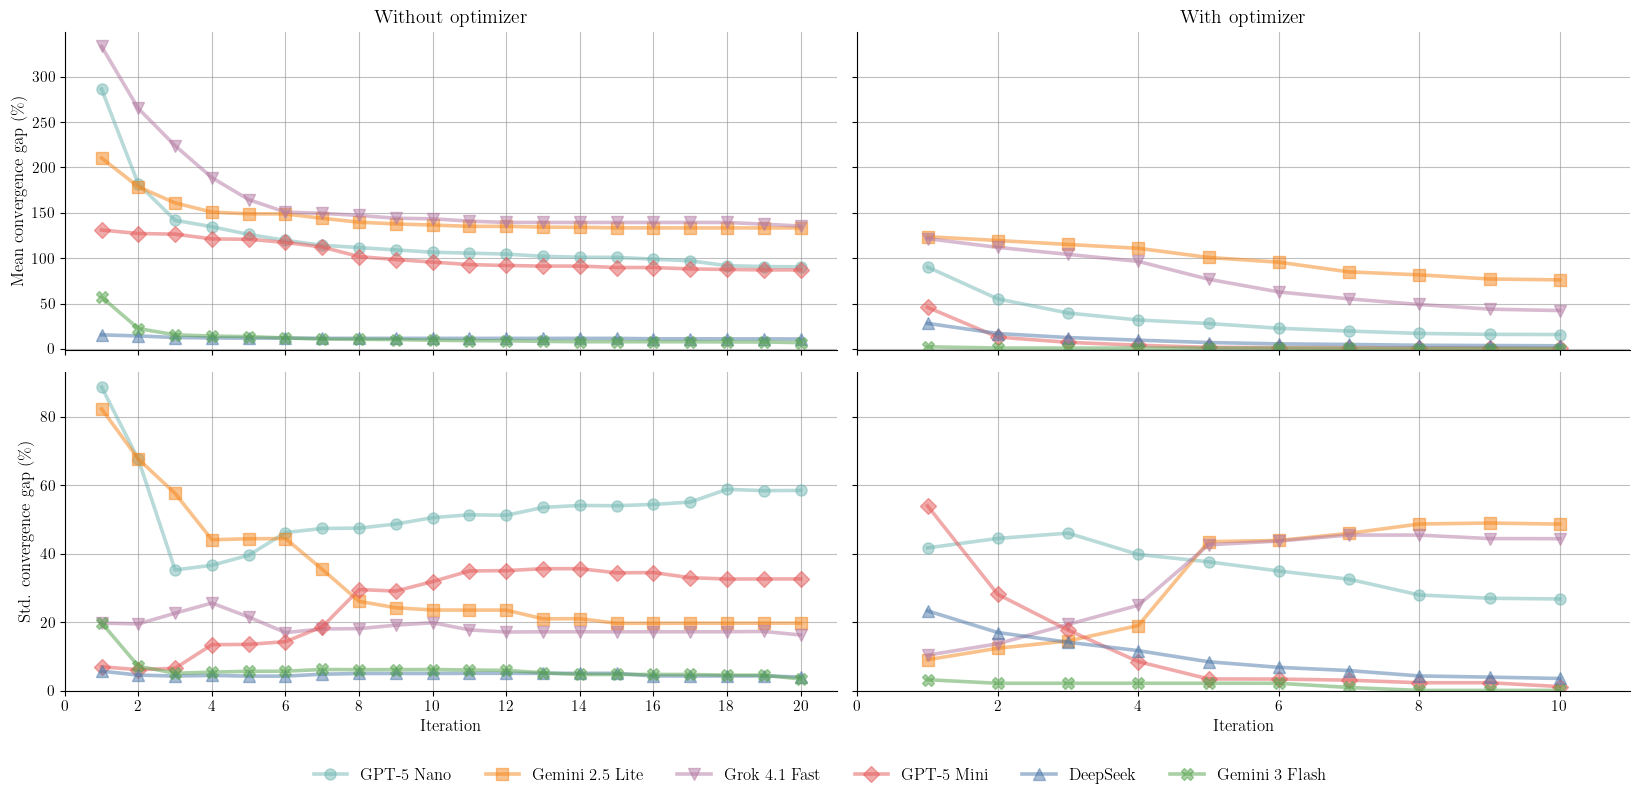

In [9]:
gap_curve_summary = (
    gap_to_baseline_summary.groupby(
        ["optimizer_status", "LLM", "n_pop"],
        dropna=False,
    )["mean_gap_to_baseline_pct"]
    .mean()
    .reset_index(name="avg_mean_gap_to_baseline_pct")
)

gap_std_curve_summary = (
    gap_to_baseline_summary.groupby(
        ["optimizer_status", "LLM", "n_pop"],
        dropna=False,
    )["std_gap_to_baseline_pct"]
    .mean()
    .reset_index(name="avg_std_gap_to_baseline_pct")
)



fig, axes = plt.subplots(2, 2, figsize=(16.5, 8.2), sharex="col", sharey='row')

plot_specs = [
    (axes[0, 0], gap_curve_summary, "without optimizer", "Without optimizer", "avg_mean_gap_to_baseline_pct", r"Mean convergence gap (\%)", -20, 20),
    (axes[0, 1], gap_curve_summary, "with optimizer", "With optimizer", "avg_mean_gap_to_baseline_pct", None, -20, 10),
    (axes[1, 0], gap_std_curve_summary, "without optimizer", None, "avg_std_gap_to_baseline_pct", r"Std. convergence gap (\%)", 0, 20),
    (axes[1, 1], gap_std_curve_summary, "with optimizer", None, "avg_std_gap_to_baseline_pct", None, 0, 10),
]

for ax, summary, optimizer_status, title, value_col, ylabel, y_min, x_max in plot_specs:
    panel_data = summary[summary["optimizer_status"].eq(optimizer_status)]
    for llm in SMARTNESS_ORDER:
        llm_curve = panel_data[panel_data["LLM"].eq(llm)].sort_values("n_pop")
        if llm_curve.empty:
            continue
        ax.plot(
            llm_curve["n_pop"],
            llm_curve[value_col],
            color=llm_colors([llm])[0],
            linewidth=2.6,
            marker=LLM_MARKERS[llm],
            markersize=8,
            label=LLM_LEGEND_LABELS[llm],
            alpha=.5,
        )

    if title is not None:
        ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_xlim(0, x_max + 1)
    ax.set_xticks(range(0, x_max + 1, 2))
    ax.set_ylim(bottom=max(-1, y_min))
    ax.grid(True, alpha=0.5, color="gray")
    format_axis(ax, tick_size=11, label_size=12, title_size=14, rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1, 0].set_xlabel(r"Iteration")
axes[1, 1].set_xlabel(r"Iteration")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.0),
    ncol=6,
    fontsize=12,
    frameon=False,
)
fig.tight_layout(rect=[0, 0.06, 1, 0.98])
fig.savefig("plots/different_llm_gap_to_baseline_mean_std_grid.pdf", bbox_inches="tight")
plt.show()


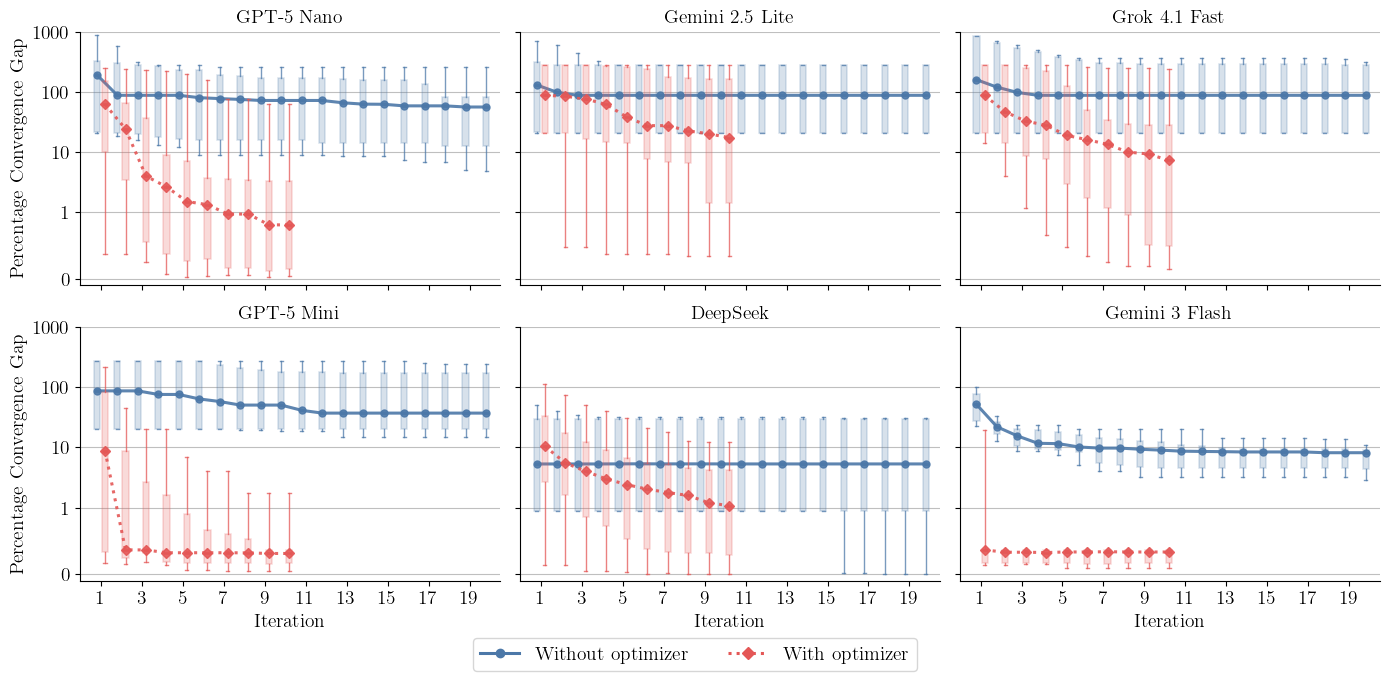

In [38]:
from matplotlib.ticker import ScalarFormatter

Y_LIM = (0, 1000)

optimizer_boxplot_styles = {
    "without optimizer": {
        "label": "Without optimizer",
        "color": "#4C78A8",
        "marker": "o",
        "linestyle": "-",
        "offset": -0.2,
    },
    "with optimizer": {
        "label": "With optimizer",
        "color": "#E45756",
        "marker": "D",
        "linestyle": ":",
        "offset": 0.2,
    },
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        linestyle=style["linestyle"],
        lw=2.2,
        label=style["label"],
    )
    for style in optimizer_boxplot_styles.values()
]

for ax, llm in zip(axes, SMARTNESS_ORDER):
    llm_data = gap_long[gap_long["LLM"].eq(llm)]
    for optimizer_status, style in optimizer_boxplot_styles.items():
        status_data = llm_data[llm_data["optimizer_status"].eq(optimizer_status)]
        n_pop_values = sorted(status_data["n_pop"].dropna().unique())
        box_values = [
            status_data.loc[status_data["n_pop"].eq(n_pop), "gap_to_baseline_pct"].dropna()
            for n_pop in n_pop_values
        ]
        if not box_values:
            continue
        positions = [n_pop + style["offset"] for n_pop in n_pop_values]
        bp = ax.boxplot(
            box_values,
            positions=positions,
            widths=0.3,
            patch_artist=True,
            showfliers=False,
            showmeans=False,
            manage_ticks=False,
            whis=(5, 95),
            boxprops=dict(facecolor=style["color"], edgecolor=style["color"], alpha=0.22, lw=1.1),
            medianprops=dict(color=style["color"], lw=1.8),
            whiskerprops=dict(color=style["color"], alpha=0.75, lw=1.0),
            capprops=dict(color=style["color"], alpha=0.75, lw=1.0),
            flierprops=dict(marker="", markersize=0),
        )
        median_values = [values.median() for values in box_values]
        ax.plot(
            positions,
            median_values,
            color=style["color"],
            linewidth=2.2,
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=5.0,
            alpha=0.9,
        )

    ax.set_title(LLM_LEGEND_LABELS[llm],fontsize=13)
    ax.set_yscale("symlog", linthresh=1)
    ax.set_xlim(0, 20.5)
    ax.set_xticks(range(1, 21,2))
    ax.set_ylim(-.1,1000)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.grid(True, axis="y", alpha=0.5, color="gray")
    format_axis(ax, tick_size=14, label_size=14, title_size=14, rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[3:]:
    ax.set_xlabel("Iteration",fontsize=14)
for ax in axes[::3]:
    ax.set_ylabel(r"Percentage Convergence Gap",fontsize=14)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0),
    ncol=2,
    fontsize=14,
    frameon=True,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.98])
fig.savefig("plots/different_llm_gap_boxplots_by_model.pdf", bbox_inches="tight")
plt.show()  


---
### With-Optimizer Speed and Reliability to Within 5\% of Best Cost
---

This section focuses only on rows with the optimizer enabled. To make the LLM comparison fair, it uses only the problem instances that appear for every with-optimizer LLM. The goal is to separate two related questions: how quickly an LLM gets close to the best observed cost on average, and how often it gets close at all.

For each instance $i$, keep the same best-repeat baseline used above:

$$
B_i = \min_{m,o,n,r} C_{i,m,o,n,r}.
$$

For a fixed LLM $m$ with optimizer enabled, first average the 10 repeat-level top-1 costs at each iteration:

$$
\bar{C}_{i,m,n} = \frac{1}{10}\sum_{r=1}^{10} C_{i,m,o=\mathrm{with},n,r}.
$$

Because this is a cost-minimization problem, "within 95\% of the best cost" is operationalized as being no more than 5\% above the best observed cost. Equivalently, the average top-1 cost at that iteration must satisfy

$$
\bar{C}_{i,m,n} \le 1.05 B_i.
$$

The speed metric is the first iteration at which the LLM reaches this within-5\%-of-best threshold:

$$
\tau^{95}_{i,m} = \min \{ n_{\mathrm{pop}} : \bar{C}_{i,m,n} \le 1.05 B_i \}.
$$

If the model never gets within 5\% of $B_i$ for that instance, $\tau^{95}_{i,m}$ is missing. The left plot reports the median of $\tau^{95}_{i,m}$ across only the instances where the model succeeds, so smaller is faster.

The reliability metric is the threshold-reaching rate:

$$
\mathrm{reliability}_m = 100 \times \frac{\#\{i : \tau^{95}_{i,m}\ \mathrm{exists}\}}{\#\{i\}}.
$$

The right plot reports this reliability percentage. A model can be fast but unreliable if it gets close quickly on only a few instances; a model can be reliable but slower if it gets close on many instances but needs more iterations.


In [45]:
WITHIN_BEST_GAP_PCT = 2
WITHIN_BEST_MULTIPLIER = 1 + WITHIN_BEST_GAP_PCT / 100

with_opt_gap = gap_long[gap_long["optimizer_status"].eq("with optimizer")].copy()
with_opt_llms = [llm for llm in SMARTNESS_ORDER if llm in set(with_opt_gap["LLM"])]
n_with_opt_llms = len(with_opt_llms)
with_opt_instance_llm_cols = instance_cols + ["LLM"]

with_opt_common_instances = (
    with_opt_gap[instance_cols + ["LLM"]]
    .drop_duplicates()
    .groupby(instance_cols, dropna=False)["LLM"]
    .nunique()
    .rename("n_llms")
    .reset_index()
    .query("n_llms == @n_with_opt_llms")
    .drop(columns="n_llms")
)
with_opt_gap_common = with_opt_gap.merge(with_opt_common_instances, on=instance_cols, how="inner")

with_opt_iteration_mean = (
    with_opt_gap_common.groupby(with_opt_instance_llm_cols + ["n_pop"], dropna=False)
    .agg(
        iteration_mean_top1_cost=("repeat_top1_cost", "mean"),
        baseline_best_repeat_cost=("baseline_best_repeat_cost", "first"),
    )
    .reset_index()
)
with_opt_iteration_mean["within_best_threshold"] = (
    with_opt_iteration_mean["iteration_mean_top1_cost"]
    <= WITHIN_BEST_MULTIPLIER * with_opt_iteration_mean["baseline_best_repeat_cost"]
)

with_opt_first_within_threshold = (
    with_opt_iteration_mean[with_opt_iteration_mean["within_best_threshold"]]
    .groupby(with_opt_instance_llm_cols, dropna=False)["n_pop"]
    .min()
    .rename("first_within_best_n_pop")
    .reset_index()
)
with_opt_first_within_threshold = (
    with_opt_iteration_mean[with_opt_instance_llm_cols]
    .drop_duplicates()
    .merge(with_opt_first_within_threshold, on=with_opt_instance_llm_cols, how="left")
)
with_opt_first_within_threshold["within_best_threshold"] = with_opt_first_within_threshold["first_within_best_n_pop"].notna()

with_opt_speed_reliability = (
    with_opt_first_within_threshold.groupby("LLM", dropna=False)
    .agg(
        median_first_within_best_n_pop=("first_within_best_n_pop", "median"),
        mean_first_within_best_n_pop=("first_within_best_n_pop", "mean"),
        n_instances=("within_best_threshold", "size"),
        n_within_threshold=("within_best_threshold", "sum"),
    )
    .reset_index()
)
with_opt_speed_reliability["within_threshold_rate_pct"] = (
    100 * with_opt_speed_reliability["n_within_threshold"] / with_opt_speed_reliability["n_instances"]
)
with_opt_speed_reliability["LLM_label"] = with_opt_speed_reliability["LLM"].map(LLM_LEGEND_LABELS)
with_opt_speed_reliability = with_opt_speed_reliability.sort_values(
    "LLM",
    key=lambda values: values.map({llm: idx for idx, llm in enumerate(SMARTNESS_ORDER)}),
)

# display(
#     with_opt_speed_reliability[
#         [
#             "LLM_label",
#             "median_first_within_best_n_pop",
#             "mean_first_within_best_n_pop",
#             "within_threshold_rate_pct",
#             "n_within_threshold",
#             "n_instances",
#         ]
#     ].round(2)
# )

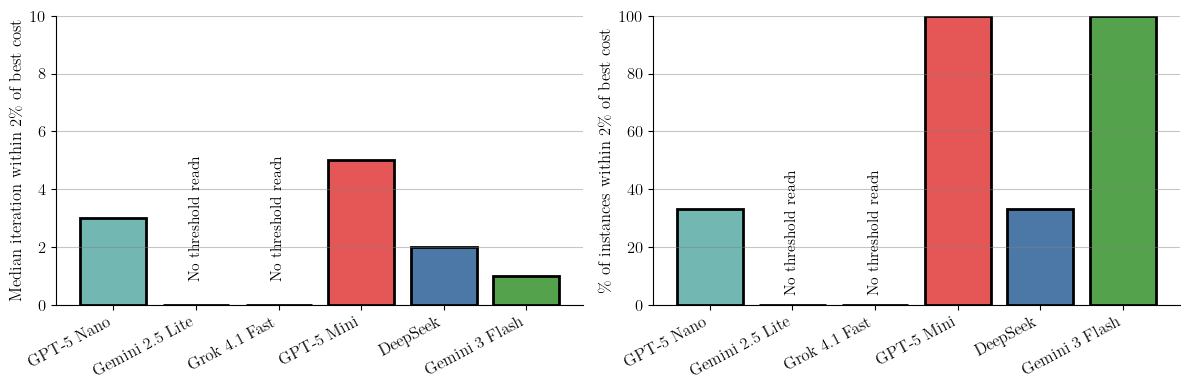

In [52]:
plot_data = with_opt_speed_reliability.set_index("LLM").reindex(
    [llm for llm in SMARTNESS_ORDER if llm in set(with_opt_speed_reliability["LLM"])]
)
plot_labels = [LLM_LEGEND_LABELS[llm] for llm in plot_data.index]
plot_colors = llm_colors(plot_data.index)
x_positions = range(len(plot_data))

FONT_SIZE = 12
ANNOTATION_FONT_SIZE = 11

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax in axes:
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(plot_labels, rotation=28, ha="right")
    ax.grid(True, axis="y", alpha=0.45, color="gray")
    format_axis(ax, tick_size=FONT_SIZE, label_size=FONT_SIZE, title_size=FONT_SIZE, rotation=28)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

speed_values = plot_data["median_first_within_best_n_pop"].fillna(0)
axes[0].bar(
    x_positions,
    speed_values,
    color=plot_colors,
    edgecolor="black",
    linewidth=2,
    alpha=1,
)
for x_pos, first_within_best in zip(x_positions, plot_data["median_first_within_best_n_pop"]):
    if pd.isna(first_within_best):
        axes[0].text(x_pos, 0.8, "No threshold reach", ha="center", va="bottom", rotation=90, fontsize=ANNOTATION_FONT_SIZE)
# axes[0].set_title("Speed: median first threshold-reaching iteration")
axes[0].set_ylabel(r"Median iteration within 2\% of best cost", fontsize=FONT_SIZE)
axes[0].set_ylim(0, 10)
axes[0].set_yticks(range(0, 12, 2))

axes[1].bar(
    x_positions,
    plot_data["within_threshold_rate_pct"],
    color=plot_colors,
    edgecolor="black",
    linewidth=2,
    alpha=1,
)
for x_pos, n_within_threshold in zip(x_positions, plot_data["n_within_threshold"]):
    if n_within_threshold == 0:
        axes[1].text(x_pos, 3, "No threshold reach", ha="center", va="bottom", rotation=90, fontsize=ANNOTATION_FONT_SIZE)
# axes[1].set_title("Reliability: threshold-reaching rate")
axes[1].set_ylabel(r"$\%$ of instances within 2$\%$ of best cost", fontsize=FONT_SIZE)
axes[1].set_ylim(0, 100)
axes[1].set_yticks(range(0, 101, 20))



fig.tight_layout()
fig.savefig("plots/different_llm_with_optimizer_speed_reliability.pdf", bbox_inches="tight")
plt.show()
